# Project Workflow Map: Notebooks 00–04

Visual overview of the pipeline from Cochrane PDF extraction through LLM evaluation.

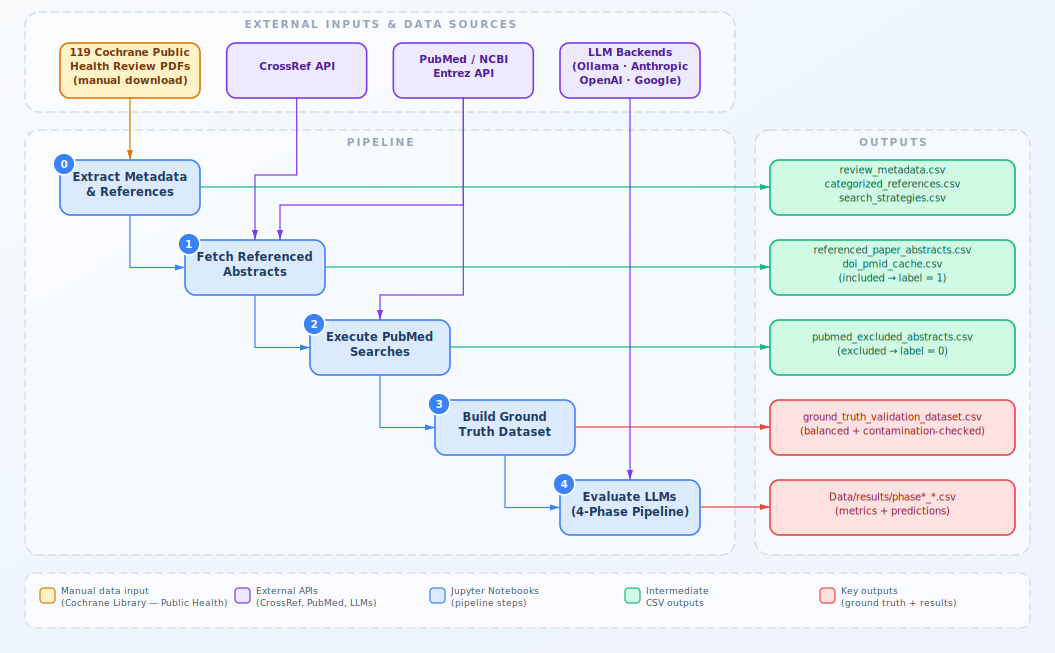

✓ Exported to: c:\Users\juanx\Documents\LSE-UKHSA Project\Visualisations\workflow_map.html


In [22]:
from IPython.display import SVG, display
from html import escape as esc

# ═══════════════════════════════════════════════════════════════
#  PROJECT WORKFLOW MAP  —  v8n
# ═══════════════════════════════════════════════════════════════

MARGIN = 25
SEC_LEFT = MARGIN

# ── Palette ──
INPUT_BG  = '#FEF3C7'; INPUT_BD = '#D97706'; INPUT_TX = '#78350F'
API_BG    = '#EDE9FE'; API_BD   = '#7C3AED'; API_TX   = '#4C1D95'
NB_BG     = '#DBEAFE'; NB_BD    = '#3B82F6'; NB_TX    = '#1E3A5F'
CSV_BG    = '#D1FAE5'; CSV_BD   = '#10B981'; CSV_TX   = '#065F46'
KEY_BG    = '#FEE2E2'; KEY_BD   = '#EF4444'; KEY_TX   = '#991B1B'
PIPE_COL  = '#3B82F6'
SECTION_BD = '#CBD5E1'

# ── Uniform box sizes ──
BOX_W, BOX_H = 140, 55
out_w, out_h = 245, 55

# ── Arrow stroke width (uniform for all arrows) ──
ARROW_SW = 1.2

# ── Section layout with equal gaps ──
SECTION_GAP = 18
input_sec_y = 12
input_sec_h = 100
input_sec_bottom = input_sec_y + input_sec_h

# Pipeline top = inputs bottom + gap
pipe_top = input_sec_bottom + SECTION_GAP

# ── Cascading notebook positions (reduced vertical spacing) ──
H_STEP, V_STEP = 125, 80
nb_pos_raw = [(i * H_STEP, pipe_top + 30 + i * V_STEP) for i in range(5)]
content_width = nb_pos_raw[4][0] + BOX_W  # rightmost edge relative to start

# ── Pipeline section width (based on content + padding) ──
PIPE_PAD = 35
pipe_sec_w = content_width + 2 * PIPE_PAD
pipe_sec_x = SEC_LEFT
pipe_sec_right = pipe_sec_x + pipe_sec_w

# ── Center content within sections ──
content_offset = SEC_LEFT + PIPE_PAD

# ── Centered notebook positions ──
nb_pos = [(content_offset + x, y) for (x, y) in nb_pos_raw]

# ── Key alignment edges ──
NB0_LEFT  = nb_pos[0][0]
NB4_RIGHT = nb_pos[4][0] + BOX_W

# ── Output section (positioned just after pipeline with small gap) ──
out_gap   = 20
out_pad   = 15
out_sec_w = out_w + 2 * out_pad
out_sec_x = pipe_sec_right + out_gap
out_x     = out_sec_x + out_pad
out_sec_right = out_sec_x + out_sec_w

# ── Pipeline vertical bounds ──
pipe_bottom = nb_pos[4][1] + BOX_H + 20
pipe_sec_h  = pipe_bottom - pipe_top

# ── Legend position (same gap as between inputs and pipeline) ──
legend_h = 55
legend_y = pipe_bottom + SECTION_GAP

# ── Calculate canvas size based on content ──
W = out_sec_right + MARGIN
H = legend_y + legend_h + MARGIN

# ── Input boxes: evenly distributed within centered content area ──
inp_span = NB4_RIGHT - NB0_LEFT
inp_gap  = (inp_span - 4 * BOX_W) / 3

inp_specs = [
    (NB0_LEFT,                              ['119 Cochrane Public', 'Health Review PDFs', '(manual download)'],
     INPUT_BG, INPUT_BD, INPUT_TX),
    (NB0_LEFT + 1 * (BOX_W + inp_gap),      ['CrossRef API'],
     API_BG,   API_BD,   API_TX),
    (NB0_LEFT + 2 * (BOX_W + inp_gap),      ['PubMed / NCBI', 'Entrez API'],
     API_BG,   API_BD,   API_TX),
    (NB0_LEFT + 3 * (BOX_W + inp_gap),      ['LLM Backends', '(Ollama · Anthropic', 'OpenAI · Google)'],
     API_BG,   API_BD,   API_TX),
]

nb_labels = [
    ['Extract Metadata', '& References'],
    ['Fetch Referenced', 'Abstracts'],
    ['Execute PubMed', 'Searches'],
    ['Build Ground', 'Truth Dataset'],
    ['Evaluate LLMs', '(4-Phase Pipeline)'],
]

out_labels = [
    (['review_metadata.csv', 'categorized_references.csv', 'search_strategies.csv'],
     CSV_BG, CSV_BD, CSV_TX),
    (['referenced_paper_abstracts.csv', 'doi_pmid_cache.csv', '(included → label = 1)'],
     CSV_BG, CSV_BD, CSV_TX),
    (['pubmed_excluded_abstracts.csv', '(excluded → label = 0)'],
     CSV_BG, CSV_BD, CSV_TX),
    (['ground_truth_validation_dataset.csv', '(balanced + contamination-checked)'],
     KEY_BG, KEY_BD, KEY_TX),
    (['Data/results/phase*_*.csv', '(metrics + predictions)'],
     KEY_BG, KEY_BD, KEY_TX),
]

# ══════════════════════════════════════════════════════════
parts = []

def rect(x, y, w, h, fill, stroke, rx=10, filt=None):
    f = f' filter="url(#{filt})"' if filt else ''
    return (f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="{rx}" '
            f'fill="{fill}" stroke="{stroke}" stroke-width="1.6"{f}/>')

def text_block(cx, cy, lines, fill, fs=12, fw='normal', ls=17):
    sy = cy - (len(lines) - 1) * ls / 2
    return ''.join(
        f'<text x="{cx}" y="{sy + i*ls}" text-anchor="middle" '
        f'font-family="Segoe UI, Helvetica, Arial, sans-serif" '
        f'font-size="{fs}" font-weight="{fw}" fill="{fill}">{esc(l)}</text>'
        for i, l in enumerate(lines))

def marker(mid, color):
    w, h = 10, 7; hw = h / 2
    return (f'<marker id="{mid}" markerWidth="{w}" markerHeight="{h}" '
            f'refX="{w}" refY="{hw}" orient="auto" markerUnits="userSpaceOnUse">'
            f'<path d="M 0,0.5 L {w},{hw} L 0,{h - 0.5} Z" '
            f'fill="{color}" stroke="none"/></marker>')

def line_a(x1, y1, x2, y2, color, sw=2, mid=''):
    m = f' marker-end="url(#{mid})"' if mid else ''
    return (f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
            f'stroke="{color}" stroke-width="{sw}"{m}/>')

def path_a(d_str, color, sw=2, mid=''):
    m  = f' marker-end="url(#{mid})"' if mid else ''
    return (f'<path d="{d_str}" fill="none" stroke="{color}" '
            f'stroke-width="{sw}"{m}/>')

def section_box(x, y, w, h, label):
    s = (f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="14" '
         f'fill="white" fill-opacity="0.45" stroke="{SECTION_BD}" '
         f'stroke-width="1.2" stroke-dasharray="8 4"/>')
    s += (f'<text x="{x + w/2}" y="{y + 16}" text-anchor="middle" '
          f'font-family="Segoe UI, Helvetica, Arial, sans-serif" '
          f'font-size="10.5" font-weight="600" fill="#94A3B8" '
          f'letter-spacing="1.8">{esc(label)}</text>')
    return s

# ── SVG open + defs ──
parts.append(f'<svg xmlns="http://www.w3.org/2000/svg" width="{W}" height="{H}" '
             f'viewBox="0 0 {W} {H}">')
parts.append('<defs>')
parts.append('<filter id="sh" x="-5%" y="-5%" width="112%" height="118%">'
             '<feDropShadow dx="1.5" dy="2.5" stdDeviation="4" flood-opacity="0.11"/></filter>')
parts.append('<filter id="shL" x="-4%" y="-4%" width="110%" height="114%">'
             '<feDropShadow dx="1" dy="1.5" stdDeviation="2.5" flood-opacity="0.07"/></filter>')
parts.append(marker('aP', PIPE_COL))
parts.append(marker('aI', INPUT_BD))
parts.append(marker('aA', API_BD))
parts.append(marker('aC', CSV_BD))
parts.append(marker('aK', KEY_BD))
parts.append('<linearGradient id="bg" x1="0" y1="0" x2="1" y2="1">'
             '<stop offset="0%" stop-color="#F8FAFC"/>'
             '<stop offset="50%" stop-color="#EFF6FF"/>'
             '<stop offset="100%" stop-color="#F0F4FF"/></linearGradient>')
parts.append('<pattern id="grid" width="40" height="40" patternUnits="userSpaceOnUse">'
             '<path d="M 40 0 L 0 40" stroke="#E2E8F0" stroke-width="0.4" opacity="0.35"/>'
             '</pattern>')
parts.append('</defs>')

# ── Background ──
parts.append(f'<rect width="{W}" height="{H}" fill="url(#bg)"/>')
parts.append(f'<rect width="{W}" height="{H}" fill="url(#grid)" opacity="0.25"/>')

# ═══════════════════════════════════════════
# THREE ALIGNED SECTION CONTAINERS
# (External Inputs aligned with Pipeline right edge)
# ═══════════════════════════════════════════
parts.append(section_box(SEC_LEFT, input_sec_y, pipe_sec_w, input_sec_h, 'EXTERNAL INPUTS & DATA SOURCES'))
parts.append(section_box(pipe_sec_x, pipe_top, pipe_sec_w, pipe_sec_h, 'PIPELINE'))
parts.append(section_box(out_sec_x, pipe_top, out_sec_w, pipe_sec_h, 'OUTPUTS'))

# ── Input boxes ──
inp_cy = input_sec_y + input_sec_h / 2 + 8
for (ix, lines, bg, bd, tx) in inp_specs:
    parts.append(rect(ix, inp_cy - BOX_H // 2, BOX_W, BOX_H, bg, bd, rx=9, filt='shL'))
    parts.append(text_block(ix + BOX_W / 2, inp_cy, lines, tx, fs=10.5, fw='600', ls=14))

# ── Notebook boxes ──
for i, (nx, ny) in enumerate(nb_pos):
    parts.append(rect(nx, ny, BOX_W, BOX_H, NB_BG, NB_BD, filt='sh'))
    bx, by = nx - 7, ny - 7
    parts.append(f'<circle cx="{bx + 11}" cy="{by + 11}" r="11" '
                 f'fill="{NB_BD}" stroke="white" stroke-width="1.8"/>')
    parts.append(f'<text x="{bx + 11}" y="{by + 15}" text-anchor="middle" '
                 f'font-family="Segoe UI, sans-serif" font-size="10.5" '
                 f'font-weight="700" fill="white">{i}</text>')
    parts.append(text_block(nx + BOX_W / 2, ny + BOX_H / 2 + 1,
                            nb_labels[i], NB_TX, fs=11.5, fw='600', ls=15))

# ── Output boxes ──
for i, (nx, ny) in enumerate(nb_pos):
    ol, obg, obd, otx = out_labels[i]
    oy = ny + (BOX_H - out_h) // 2
    parts.append(rect(out_x, oy, out_w, out_h, obg, obd, rx=9, filt='shL'))
    parts.append(text_block(out_x + out_w / 2, oy + out_h / 2,
                            ol, otx, fs=10, fw='500', ls=14))

# ── Arrows: Notebook → Notebook (straight down, then 90° right turn) ──
for i in range(4):
    sx = nb_pos[i][0] + BOX_W / 2       # bottom-centre of current box
    sy = nb_pos[i][1] + BOX_H
    ex = nb_pos[i + 1][0]               # LEFT edge of next box
    ey = nb_pos[i + 1][1] + BOX_H / 2   # vertical centre of next box
    parts.append(path_a(
        f'M {sx},{sy} L {sx},{ey} L {ex},{ey}',
        PIPE_COL, sw=ARROW_SW, mid='aP'))

# ── Arrows: Notebook → Output (horizontal solid) ──
for i, (nx, ny) in enumerate(nb_pos):
    mid = 'aC' if i < 3 else 'aK'
    col = CSV_BD if i < 3 else KEY_BD
    cy = ny + BOX_H // 2
    parts.append(line_a(nx + BOX_W, cy, out_x, cy, col, sw=ARROW_SW, mid=mid))

# ── Arrows: Inputs → Notebooks (straight lines with right-angle turns) ──
ic = [inp_specs[j][0] + BOX_W / 2 for j in range(4)]
inp_bot = inp_cy + BOX_H // 2

# Input 0 (amber) → NB0 center-top
px0, py0 = nb_pos[0]
tx0 = px0 + BOX_W / 2
mid_y0 = inp_bot + 15
parts.append(path_a(
    f'M {ic[0]},{inp_bot} L {ic[0]},{mid_y0} L {tx0},{mid_y0} L {tx0},{py0}',
    INPUT_BD, sw=ARROW_SW, mid='aI'))

# Input 1 (purple) → NB1 center-top (turn at slightly higher point)
px1, py1 = nb_pos[1]
tx1 = px1 + BOX_W / 2
mid_y1 = py1 - 65
parts.append(path_a(
    f'M {ic[1]},{inp_bot} L {ic[1]},{mid_y1} L {tx1},{mid_y1} L {tx1},{py1}',
    API_BD, sw=ARROW_SW, mid='aA'))

# Input 2 (purple) → NB1 center-top (offset target slightly to avoid overlap)
tx1b = px1 + BOX_W / 2 + 25
mid_y1b = py1 - 35
parts.append(path_a(
    f'M {ic[2]},{inp_bot} L {ic[2]},{mid_y1b} L {tx1b},{mid_y1b} L {tx1b},{py1}',
    API_BD, sw=ARROW_SW, mid='aA'))

# Input 2 (purple) → NB2 center-top
px2, py2 = nb_pos[2]
tx2 = px2 + BOX_W / 2
mid_y2 = py2 - 25
parts.append(path_a(
    f'M {ic[2]},{inp_bot} L {ic[2]},{mid_y2} L {tx2},{mid_y2} L {tx2},{py2}',
    API_BD, sw=ARROW_SW, mid='aA'))

# Input 3 (purple) → NB4 center-top
px4, py4 = nb_pos[4]
tx4 = px4 + BOX_W / 2
mid_y4 = py4 - 25
parts.append(path_a(
    f'M {ic[3]},{inp_bot} L {ic[3]},{mid_y4} L {tx4},{mid_y4} L {tx4},{py4}',
    API_BD, sw=ARROW_SW, mid='aA'))

# ── Legend (aligned to outputs right edge, equal gap from pipeline) ──
legend_w = out_sec_right - SEC_LEFT
parts.append(f'<rect x="{SEC_LEFT}" y="{legend_y}" width="{legend_w}" height="{legend_h}" '
             f'rx="10" fill="white" fill-opacity="0.6" stroke="{SECTION_BD}" '
             f'stroke-width="1" stroke-dasharray="8 4"/>')

# Two-line legend labels
legend = [
    (INPUT_BG, INPUT_BD, ['Manual data input', '(Cochrane Library — Public Health)']),
    (API_BG,   API_BD,   ['External APIs', '(CrossRef, PubMed, LLMs)']),
    (NB_BG,    NB_BD,    ['Jupyter Notebooks', '(pipeline steps)']),
    (CSV_BG,   CSV_BD,   ['Intermediate', 'CSV outputs']),
    (KEY_BG,   KEY_BD,   ['Key outputs', '(ground truth + results)']),
]
sp = (legend_w - 30) // len(legend)
ly = legend_y + 15  # vertical offset for content within legend box
for j, (bg, bd, lines) in enumerate(legend):
    lx = SEC_LEFT + 15 + j * sp
    parts.append(f'<rect x="{lx}" y="{ly}" width="15" height="15" rx="3.5" '
                 f'fill="{bg}" stroke="{bd}" stroke-width="1.2"/>')
    # Two-line text
    parts.append(f'<text x="{lx + 21}" y="{ly + 6}" '
                 f'font-family="Segoe UI, Helvetica, Arial, sans-serif" '
                 f'font-size="9" fill="#475569">{esc(lines[0])}</text>')
    parts.append(f'<text x="{lx + 21}" y="{ly + 18}" '
                 f'font-family="Segoe UI, Helvetica, Arial, sans-serif" '
                 f'font-size="9" fill="#475569">{esc(lines[1])}</text>')

parts.append('</svg>')

# ── Build SVG string ──
svg_content = '\n'.join(parts)

# ── Display in notebook ──
display(SVG(data=svg_content))

# ── Export to HTML with zoom/pan controls ──
html_template = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Project Workflow Map</title>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{
            font-family: 'Segoe UI', Helvetica, Arial, sans-serif;
            background: linear-gradient(135deg, #F8FAFC 0%, #EFF6FF 50%, #F0F4FF 100%);
            min-height: 100vh;
            overflow: hidden;
        }}
        
        .controls {{
            position: fixed;
            top: 20px;
            left: 20px;
            z-index: 1000;
            background: rgba(255,255,255,0.95);
            padding: 15px 20px;
            border-radius: 12px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.1);
            display: flex;
            gap: 10px;
            align-items: center;
        }}
        
        .controls button {{
            padding: 8px 16px;
            border: none;
            border-radius: 6px;
            cursor: pointer;
            font-size: 14px;
            font-weight: 500;
            transition: all 0.2s;
        }}
        
        .zoom-btn {{
            background: #3B82F6;
            color: white;
            width: 36px;
            height: 36px;
            padding: 0;
            font-size: 18px;
            font-weight: bold;
        }}
        
        .zoom-btn:hover {{ background: #2563EB; }}
        
        .reset-btn {{
            background: #64748B;
            color: white;
        }}
        
        .reset-btn:hover {{ background: #475569; }}
        
        .preset-btn {{
            background: #E2E8F0;
            color: #334155;
        }}
        
        .preset-btn:hover {{ background: #CBD5E1; }}
        .preset-btn.active {{ background: #3B82F6; color: white; }}
        
        .zoom-level {{
            font-size: 13px;
            color: #64748B;
            min-width: 50px;
            text-align: center;
        }}
        
        .divider {{
            width: 1px;
            height: 24px;
            background: #CBD5E1;
            margin: 0 5px;
        }}
        
        .svg-container {{
            width: 100vw;
            height: 100vh;
            overflow: hidden;
            cursor: grab;
        }}
        
        .svg-container:active {{ cursor: grabbing; }}
        
        .svg-wrapper {{
            transform-origin: 0 0;
            transition: transform 0.1s ease-out;
        }}
        
        .help {{
            position: fixed;
            bottom: 20px;
            left: 20px;
            background: rgba(255,255,255,0.9);
            padding: 12px 16px;
            border-radius: 8px;
            font-size: 12px;
            color: #64748B;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        }}
        
        .help kbd {{
            background: #E2E8F0;
            padding: 2px 6px;
            border-radius: 4px;
            font-family: inherit;
        }}
    </style>
</head>
<body>
    <div class="controls">
        <button class="zoom-btn" onclick="zoomIn()">+</button>
        <span class="zoom-level" id="zoomLevel">100%</span>
        <button class="zoom-btn" onclick="zoomOut()">−</button>
        <div class="divider"></div>
        <button class="reset-btn" onclick="resetView()">Reset</button>
        <div class="divider"></div>
        <button class="preset-btn" onclick="focusOn('inputs')">Inputs</button>
        <button class="preset-btn" onclick="focusOn('pipeline')">Pipeline</button>
        <button class="preset-btn" onclick="focusOn('outputs')">Outputs</button>
        <button class="preset-btn" onclick="focusOn('all')">Full View</button>
    </div>
    
    <div class="help">
        <kbd>Scroll</kbd> to zoom &nbsp;|&nbsp; <kbd>Drag</kbd> to pan &nbsp;|&nbsp; <kbd>Double-click</kbd> to zoom in
    </div>
    
    <div class="svg-container" id="container">
        <div class="svg-wrapper" id="wrapper">
            {svg_content}
        </div>
    </div>

    <script>
        const container = document.getElementById('container');
        const wrapper = document.getElementById('wrapper');
        const zoomLevelDisplay = document.getElementById('zoomLevel');
        
        let scale = 1;
        let translateX = 50;
        let translateY = 50;
        let isDragging = false;
        let startX, startY;
        
        const MIN_SCALE = 0.3;
        const MAX_SCALE = 4;
        const ZOOM_STEP = 0.15;
        
        const presets = {{
            inputs: {{ x: -20, y: 20, scale: 2 }},
            pipeline: {{ x: 50, y: -100, scale: 1.3 }},
            outputs: {{ x: -550, y: -100, scale: 1.5 }},
            all: {{ x: 50, y: 50, scale: 1 }}
        }};
        
        function updateTransform(smooth = true) {{
            wrapper.style.transition = smooth ? 'transform 0.3s ease-out' : 'transform 0.05s ease-out';
            wrapper.style.transform = `translate(${{translateX}}px, ${{translateY}}px) scale(${{scale}})`;
            zoomLevelDisplay.textContent = Math.round(scale * 100) + '%';
        }}
        
        function zoomIn() {{
            scale = Math.min(MAX_SCALE, scale + ZOOM_STEP);
            updateTransform();
        }}
        
        function zoomOut() {{
            scale = Math.max(MIN_SCALE, scale - ZOOM_STEP);
            updateTransform();
        }}
        
        function resetView() {{
            scale = 1;
            translateX = 50;
            translateY = 50;
            updateTransform();
            clearActivePresets();
        }}
        
        function focusOn(preset) {{
            const p = presets[preset];
            scale = p.scale;
            translateX = p.x;
            translateY = p.y;
            updateTransform();
            
            clearActivePresets();
            event.target.classList.add('active');
        }}
        
        function clearActivePresets() {{
            document.querySelectorAll('.preset-btn').forEach(btn => btn.classList.remove('active'));
        }}
        
        container.addEventListener('wheel', (e) => {{
            e.preventDefault();
            const delta = e.deltaY > 0 ? -ZOOM_STEP : ZOOM_STEP;
            const newScale = Math.max(MIN_SCALE, Math.min(MAX_SCALE, scale + delta));
            
            const rect = container.getBoundingClientRect();
            const mouseX = e.clientX - rect.left;
            const mouseY = e.clientY - rect.top;
            
            const scaleChange = newScale / scale;
            translateX = mouseX - (mouseX - translateX) * scaleChange;
            translateY = mouseY - (mouseY - translateY) * scaleChange;
            
            scale = newScale;
            updateTransform(false);
        }}, {{ passive: false }});
        
        container.addEventListener('mousedown', (e) => {{
            isDragging = true;
            startX = e.clientX - translateX;
            startY = e.clientY - translateY;
            container.style.cursor = 'grabbing';
        }});
        
        document.addEventListener('mousemove', (e) => {{
            if (!isDragging) return;
            translateX = e.clientX - startX;
            translateY = e.clientY - startY;
            updateTransform(false);
        }});
        
        document.addEventListener('mouseup', () => {{
            isDragging = false;
            container.style.cursor = 'grab';
        }});
        
        container.addEventListener('dblclick', (e) => {{
            const rect = container.getBoundingClientRect();
            const mouseX = e.clientX - rect.left;
            const mouseY = e.clientY - rect.top;
            
            const newScale = Math.min(MAX_SCALE, scale + 0.5);
            const scaleChange = newScale / scale;
            translateX = mouseX - (mouseX - translateX) * scaleChange;
            translateY = mouseY - (mouseY - translateY) * scaleChange;
            
            scale = newScale;
            updateTransform();
        }});
        
        document.addEventListener('keydown', (e) => {{
            if (e.key === '+' || e.key === '=') zoomIn();
            if (e.key === '-') zoomOut();
            if (e.key === '0') resetView();
            if (e.key === 'Escape') resetView();
        }});
        
        updateTransform();
    </script>
</body>
</html>'''

# Write to file
output_path = r'c:\Users\juanx\Documents\LSE-UKHSA Project\Visualisations\workflow_map.html'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html_template)

print(f"✓ Exported to: {output_path}")